In [5]:
import warnings
warnings.filterwarnings('ignore')

import json, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

from xgboost import XGBRegressor
import pulp

os.makedirs('outputs', exist_ok=True)
pd.set_option('display.max_columns', 50)
plt.rcParams['figure.figsize'] = (10, 4)
np.random.seed(42)

In [6]:
!pip install pulp

In [7]:
DATA_PATH = 'sl_railway_ticketing_2020_2024.csv'
df = pd.read_csv(DATA_PATH)
df['date'] = pd.to_datetime(df['date'])

print('Shape:', df.shape)
print('Date range:', df['date'].min().date(), 'to', df['date'].max().date())
print('Classes:', df['class'].unique())
df.head()

Shape: (55302, 21)
Date range: 2020-01-01 to 2024-12-31
Classes: <ArrowStringArray>
['1st Class', '2nd Class', '3rd Class']
Length: 3, dtype: str


,record_id,date,year,month,day_of_week,day_type,is_public_holiday,holiday_name,is_covid_lockdown_period,origin_station,destination_station,line_name,distance_km,train_type,class,seat_capacity,tickets_sold,seat_utilization_pct,fare_lkr,revenue_lkr,delay_minutes
0,1,2020-01-01,2020,1,Wednesday,Weekday,1,New Year's Day,0,Maradana,Avissawella,Kelani Valley Line,58,Intercity,1st Class,37,32,86.49,671.14,21476.48,3
1,2,2020-01-01,2020,1,Wednesday,Weekday,1,New Year's Day,0,Maradana,Avissawella,Kelani Valley Line,58,Intercity,2nd Class,225,225,100.00,358.18,80590.50,9
2,3,2020-01-01,2020,1,Wednesday,Weekday,1,New Year's Day,0,Maradana,Avissawella,Kelani Valley Line,58,Intercity,3rd Class,487,487,100.00,187.67,91395.29,0
3,4,2020-01-01,2020,1,Wednesday,Weekday,1,New Year's Day,0,Colombo Fort,Ratnapura,Main Line branch,101,Night Mail,1st Class,32,26,81.25,1162.38,30221.88,14
4,5,2020-01-01,2020,1,Wednesday,Weekday,1,New Year's Day,0,Colombo Fort,Ratnapura,Main Line branch,101,Night Mail,2nd Class,195,180,92.31,688.22,123879.60,19


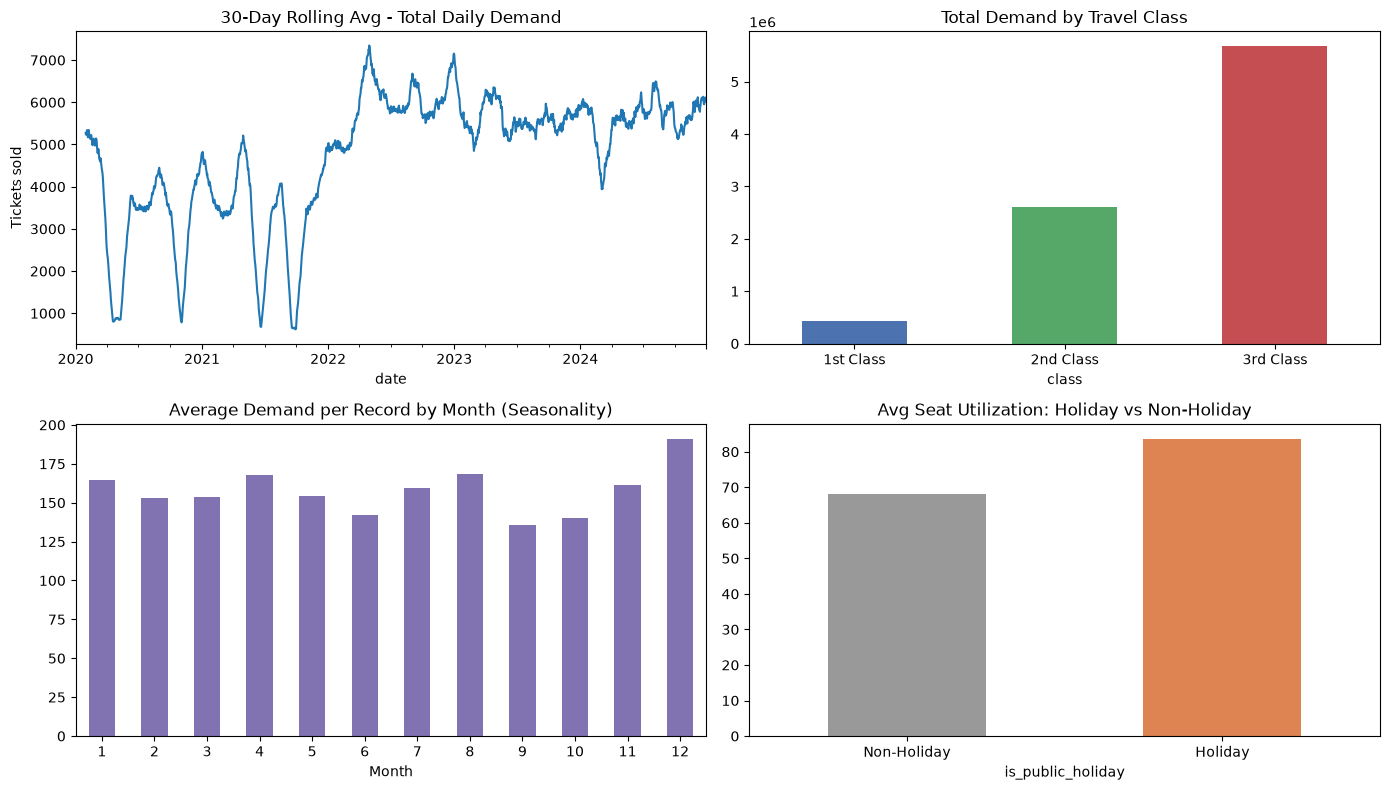

In [8]:
daily_demand = df.groupby('date')['tickets_sold'].sum()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

daily_demand.rolling(30).mean().plot(ax=axes[0,0], title='30-Day Rolling Avg - Total Daily Demand')
axes[0,0].set_ylabel('Tickets sold')

df.groupby('class')['tickets_sold'].sum().reindex(['1st Class','2nd Class','3rd Class']).plot(
    kind='bar', ax=axes[0,1], color=['#4C72B0','#55A868','#C44E52'])
axes[0,1].set_title('Total Demand by Travel Class')
axes[0,1].set_xticklabels(axes[0,1].get_xticklabels(), rotation=0)

df.groupby(df['date'].dt.month)['tickets_sold'].mean().plot(kind='bar', ax=axes[1,0], color='#8172B2')
axes[1,0].set_title('Average Demand per Record by Month (Seasonality)')
axes[1,0].set_xlabel('Month')
axes[1,0].tick_params(axis='x', rotation=0)

df.groupby('is_public_holiday')['seat_utilization_pct'].mean().plot(kind='bar', ax=axes[1,1], color=['#999999','#DD8452'])
axes[1,1].set_title('Avg Seat Utilization: Holiday vs Non-Holiday')
axes[1,1].set_xticklabels(['Non-Holiday','Holiday'], rotation=0)

plt.tight_layout()
plt.savefig('outputs/eda_overview.png', dpi=120)
plt.show()

In [9]:
data = df.copy()

# --- Date-derived features ---
data['dayofweek'] = data['date'].dt.dayofweek
data['day'] = data['date'].dt.day
data['weekofyear'] = data['date'].dt.isocalendar().week.astype(int)
data['is_weekend'] = (data['dayofweek'] >= 5).astype(int)

# Cyclical encoding (so the model understands month 12 is close to month 1)
data['month_sin'] = np.sin(2*np.pi*data['month']/12)
data['month_cos'] = np.cos(2*np.pi*data['month']/12)
data['dow_sin'] = np.sin(2*np.pi*data['dayofweek']/7)
data['dow_cos'] = np.cos(2*np.pi*data['dayofweek']/7)

# --- Route identifier ---
data['route'] = data['origin_station'] + ' - ' + data['destination_station']

# --- Lag / rolling features per (route, train_type, class) series ---
data = data.sort_values(['route', 'train_type', 'class', 'date'])
grp = data.groupby(['route', 'train_type', 'class'])['tickets_sold']
data['lag_1']      = grp.shift(1)
data['lag_7']      = grp.shift(7)
data['roll_mean_7']  = grp.transform(lambda s: s.shift(1).rolling(7,  min_periods=1).mean())
data['roll_mean_30'] = grp.transform(lambda s: s.shift(1).rolling(30, min_periods=1).mean())

# Fill early-series NaNs (first few records of each series) with that series' overall mean
for c in ['lag_1', 'lag_7', 'roll_mean_7', 'roll_mean_30']:
    data[c] = data.groupby(['route','train_type','class'])[c].transform(lambda s: s.fillna(s.mean()))
data[['lag_1','lag_7','roll_mean_7','roll_mean_30']] = data[['lag_1','lag_7','roll_mean_7','roll_mean_30']].fillna(0)

# --- Categorical encoding ---
cat_cols = ['route', 'train_type', 'class', 'line_name', 'day_type']
encoders = {}
for c in cat_cols:
    le = LabelEncoder()
    data[c + '_enc'] = le.fit_transform(data[c])
    encoders[c] = le

feature_cols = [
    'route_enc', 'train_type_enc', 'class_enc', 'line_name_enc', 'day_type_enc',
    'distance_km', 'seat_capacity', 'is_public_holiday', 'is_covid_lockdown_period',
    'month', 'dayofweek', 'day', 'weekofyear', 'is_weekend',
    'month_sin', 'month_cos', 'dow_sin', 'dow_cos',
    'lag_1', 'lag_7', 'roll_mean_7', 'roll_mean_30'
]
target_col = 'tickets_sold'

print('Feature matrix shape:', data[feature_cols].shape)
data[feature_cols + [target_col, 'class']].head()

Feature matrix shape: (55302, 22)


,route_enc,train_type_enc,class_enc,line_name_enc,day_type_enc,distance_km,seat_capacity,is_public_holiday,is_covid_lockdown_period,month,dayofweek,day,weekofyear,is_weekend,month_sin,month_cos,dow_sin,dow_cos,lag_1,lag_7,roll_mean_7,roll_mean_30,tickets_sold,class
138,0,0,0,5,1,205,45,0,0,1,6,5,1,1,0.5,0.866025,-0.781831,0.623490,30.354545,30.296296,30.272677,29.961965,31,1st Class
195,0,0,0,5,0,205,45,0,0,1,1,7,2,0,0.5,0.866025,0.781831,0.623490,31.000000,30.296296,31.000000,31.000000,18,1st Class
492,0,0,0,5,0,205,45,0,0,1,3,16,3,0,0.5,0.866025,0.433884,-0.900969,18.000000,30.296296,24.500000,24.500000,38,1st Class
552,0,0,0,5,1,205,45,0,0,1,5,18,3,1,0.5,0.866025,-0.974928,-0.222521,38.000000,30.296296,29.000000,29.000000,40,1st Class
561,0,0,0,5,1,205,45,0,0,1,5,18,3,1,0.5,0.866025,-0.974928,-0.222521,40.000000,30.296296,31.750000,31.750000,30,1st Class


In [10]:
train_mask = data['date'] < '2024-01-01'
test_mask  = data['date'] >= '2024-01-01'

X_train, y_train = data.loc[train_mask, feature_cols], data.loc[train_mask, target_col]
X_test,  y_test  = data.loc[test_mask, feature_cols],  data.loc[test_mask, target_col]

print('Train rows:', X_train.shape[0], '| Test rows:', X_test.shape[0])

Train rows: 44928 | Test rows: 10374


In [11]:
models = {
    'RandomForest': RandomForestRegressor(n_estimators=300, max_depth=14, random_state=42, n_jobs=-1),
    'XGBoost': XGBRegressor(n_estimators=400, max_depth=6, learning_rate=0.05,
                             subsample=0.9, colsample_bytree=0.9, random_state=42, n_jobs=-1)
}

trained_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mape = np.mean(np.abs((y_test - preds) / y_test.replace(0, 1))) * 100
    print(f'{name:15s} | MAE: {mae:6.2f}  RMSE: {rmse:6.2f}  MAPE: {mape:5.2f}%')

# Pick the best model (lowest MAE) as the production forecaster
best_name = min(trained_models, key=lambda n: mean_absolute_error(y_test, trained_models[n].predict(X_test)))
best_model = trained_models[best_name]
print(f'\nSelected model: {best_name}')

RandomForest    | MAE:  24.10  RMSE:  37.67  MAPE: 13.12%
XGBoost         | MAE:  24.20  RMSE:  38.13  MAPE: 13.43%

Selected model: RandomForest


In [12]:
data.loc[test_mask, 'predicted_demand'] = best_model.predict(X_test)

class_metrics = []
for cls in ['1st Class', '2nd Class', '3rd Class']:
    sub = data.loc[test_mask & (data['class'] == cls)]
    mae = mean_absolute_error(sub[target_col], sub['predicted_demand'])
    rmse = np.sqrt(mean_squared_error(sub[target_col], sub['predicted_demand']))
    mape = np.mean(np.abs((sub[target_col] - sub['predicted_demand']) / sub[target_col].replace(0,1))) * 100
    class_metrics.append({'class': cls, 'MAE': round(mae,2), 'RMSE': round(rmse,2), 'MAPE_%': round(mape,2)})

class_metrics_df = pd.DataFrame(class_metrics)
class_metrics_df.to_csv('outputs/class_wise_metrics.csv', index=False)
class_metrics_df

,class,MAE,RMSE,MAPE_%
0,1st Class,3.60,4.51,13.11
1,2nd Class,21.45,26.82,13.09
2,3rd Class,47.27,59.32,13.15


In [14]:
!pip install tensorflow

ERROR: Could not find a version that satisfies the requirement tensorflow (from versions: none)
ERROR: No matching distribution found for tensorflow


In [15]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)

daily = df.groupby('date')['tickets_sold'].sum().asfreq('D').ffill()

scaler = MinMaxScaler()
scaled = scaler.fit_transform(daily.values.reshape(-1,1))

LOOKBACK = 14
X_seq, y_seq, dates_seq = [], [], []
for i in range(LOOKBACK, len(scaled)):
    X_seq.append(scaled[i-LOOKBACK:i, 0])
    y_seq.append(scaled[i, 0])
    dates_seq.append(daily.index[i])
X_seq, y_seq = np.array(X_seq), np.array(y_seq)
X_seq = X_seq.reshape((X_seq.shape[0], X_seq.shape[1], 1))

split_idx = np.searchsorted(dates_seq, pd.Timestamp('2024-01-01'))
X_seq_train, X_seq_test = X_seq[:split_idx], X_seq[split_idx:]
y_seq_train, y_seq_test = y_seq[:split_idx], y_seq[split_idx:]
dates_test = np.array(dates_seq)[split_idx:]

lstm = keras.Sequential([
    layers.Input(shape=(LOOKBACK, 1)),
    layers.LSTM(64, return_sequences=True),
    layers.Dropout(0.2),
    layers.LSTM(32),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)
])
lstm.compile(optimizer='adam', loss='mse')
history = lstm.fit(X_seq_train, y_seq_train, epochs=30, batch_size=16,
                    validation_split=0.1, verbose=0)

pred_scaled = lstm.predict(X_seq_test, verbose=0)
pred_actual = scaler.inverse_transform(pred_scaled).flatten()
true_actual = scaler.inverse_transform(y_seq_test.reshape(-1,1)).flatten()

lstm_mae = mean_absolute_error(true_actual, pred_actual)
lstm_rmse = np.sqrt(mean_squared_error(true_actual, pred_actual))
print(f'LSTM aggregate daily-demand forecast -> MAE: {lstm_mae:.1f}  RMSE: {lstm_rmse:.1f}')

actual_vs_pred = pd.DataFrame({
    'date': dates_test,
    'actual_demand': true_actual.round(0).astype(int),
    'predicted_demand': pred_actual.round(0).astype(int)
})
actual_vs_pred.to_csv('outputs/actual_vs_predicted.csv', index=False)

plt.figure(figsize=(12,4))
plt.plot(actual_vs_pred['date'], actual_vs_pred['actual_demand'], label='Actual')
plt.plot(actual_vs_pred['date'], actual_vs_pred['predicted_demand'], label='Predicted')
plt.title('Actual vs Predicted Total Daily Demand (2024, LSTM)')
plt.legend()
plt.tight_layout()
plt.savefig('outputs/actual_vs_predicted.png', dpi=120)
plt.show()

ModuleNotFoundError: No module named 'tensorflow'

{'peak_day_of_week': 'Friday', 'lowest_day_of_week': 'Wednesday', 'peak_month': 12, 'lowest_month': 9, 'holiday_utilization_uplift_pct': np.float64(23.0)}


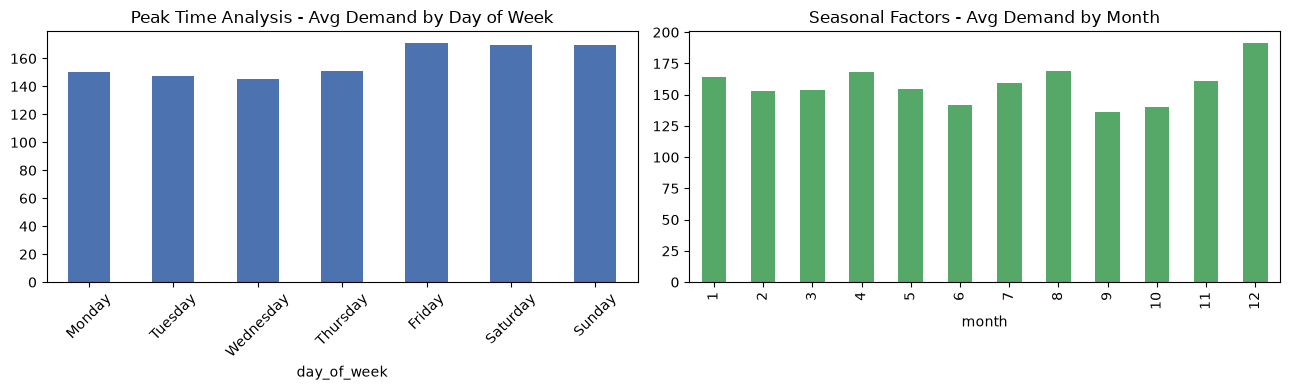

In [16]:
peak_dow = df.groupby('day_of_week')['tickets_sold'].mean().reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
peak_month = df.groupby('month')['tickets_sold'].mean()

holiday_factor = (df.groupby('is_public_holiday')['seat_utilization_pct'].mean())
holiday_uplift_pct = round((holiday_factor[1] / holiday_factor[0] - 1) * 100, 1)

peak_dow.to_csv('outputs/peak_time_by_dayofweek.csv', header=['avg_tickets_sold'])
peak_month.to_csv('outputs/seasonal_factors_by_month.csv', header=['avg_tickets_sold'])

seasonal_holiday_summary = {
    'peak_day_of_week': peak_dow.idxmax(),
    'lowest_day_of_week': peak_dow.idxmin(),
    'peak_month': int(peak_month.idxmax()),
    'lowest_month': int(peak_month.idxmin()),
    'holiday_utilization_uplift_pct': holiday_uplift_pct
}
with open('outputs/seasonal_holiday_summary.json', 'w') as f:
    json.dump(seasonal_holiday_summary, f, indent=2)

print(seasonal_holiday_summary)

fig, ax = plt.subplots(1, 2, figsize=(13,4))
peak_dow.plot(kind='bar', ax=ax[0], color='#4C72B0', title='Peak Time Analysis - Avg Demand by Day of Week')
ax[0].tick_params(axis='x', rotation=45)
peak_month.plot(kind='bar', ax=ax[1], color='#55A868', title='Seasonal Factors - Avg Demand by Month')
plt.tight_layout()
plt.savefig('outputs/peak_seasonal_analysis.png', dpi=120)
plt.show()

In [17]:
FAIRNESS_FLOOR = 0.70   # every class keeps at least 70% of its base capacity
FLEX_CAP       = 1.20   # a class can grow at most 20% beyond its base capacity

def allocate_seats_for_train(base_caps: dict, predicted_demand: dict):
    """base_caps, predicted_demand: {'1st Class': x, '2nd Class': y, '3rd Class': z}"""
    total_capacity = sum(base_caps.values())
    classes = list(base_caps.keys())

    prob = pulp.LpProblem('SeatAllocation', pulp.LpMaximize)
    alloc = {c: pulp.LpVariable(f'alloc_{c}', lowBound=0, cat='Integer') for c in classes}
    satisfied = {c: pulp.LpVariable(f'satisfied_{c}', lowBound=0, cat='Integer') for c in classes}

    prob += pulp.lpSum(satisfied.values())  # maximize total satisfied demand

    prob += pulp.lpSum(alloc.values()) == total_capacity
    for c in classes:
        prob += alloc[c] >= FAIRNESS_FLOOR * base_caps[c]
        prob += alloc[c] <= FLEX_CAP * base_caps[c]
        prob += satisfied[c] <= alloc[c]
        prob += satisfied[c] <= predicted_demand[c]

    prob.solve(pulp.PULP_CBC_CMD(msg=0))
    return {c: int(alloc[c].value()) for c in classes}

# --- quick sanity check on one example train service ---
example_caps = {'1st Class': 37, '2nd Class': 225, '3rd Class': 487}
example_demand = {'1st Class': 60, '2nd Class': 150, '3rd Class': 500}
print('Example allocation:', allocate_seats_for_train(example_caps, example_demand))

Example allocation: {'1st Class': 44, '2nd Class': 158, '3rd Class': 547}


In [ ]:
test_df = data.loc[test_mask, ['date','route','train_type','class','seat_capacity','predicted_demand', target_col]].copy()
test_df['predicted_demand'] = test_df['predicted_demand'].clip(lower=0).round().astype(int)

alloc_records = []
group_cols = ['date','route','train_type']
for (d, route, ttype), grp in test_df.groupby(group_cols):
    base_caps = dict(zip(grp['class'], grp['seat_capacity']))
    pred_dem  = dict(zip(grp['class'], grp['predicted_demand']))
    # ensure all 3 classes present
    if len(base_caps) < 3:
        continue
    allocation = allocate_seats_for_train(base_caps, pred_dem)
    for cls in base_caps:
        alloc_records.append({
            'date': d, 'route': route, 'train_type': ttype, 'class': cls,
            'base_capacity': base_caps[cls],
            'predicted_demand': pred_dem[cls],
            'allocated_seats': allocation[cls],
            'actual_tickets_sold': int(grp.loc[grp['class']==cls, target_col].values[0])
        })

alloc_df = pd.DataFrame(alloc_records)
alloc_df['seat_utilization_pct'] = (alloc_df[['allocated_seats','predicted_demand']].min(axis=1)
                                     / alloc_df['allocated_seats'] * 100).round(2)
alloc_df.to_csv('outputs/seat_allocation_results.csv', index=False)
print('Allocation rows generated:', len(alloc_df))
alloc_df.head(10)

In [ ]:
class_alloc_summary = alloc_df.groupby('class').agg(
    total_base_capacity=('base_capacity','sum'),
    total_allocated_seats=('allocated_seats','sum'),
    total_predicted_demand=('predicted_demand','sum'),
    avg_utilization_pct=('seat_utilization_pct','mean')
).reindex(['1st Class','2nd Class','3rd Class']).round(2)

class_alloc_summary.to_csv('outputs/class_wise_allocation_summary.csv')
class_alloc_summary

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13,4))
class_alloc_summary[['total_base_capacity','total_allocated_seats','total_predicted_demand']].plot(
    kind='bar', ax=axes[0], title='Class-wise Allocation vs Predicted Demand')
axes[0].tick_params(axis='x', rotation=0)

class_alloc_summary['avg_utilization_pct'].plot(kind='bar', ax=axes[1], color='#C44E52',
                                                 title='Seat Utilization % by Class')
axes[1].tick_params(axis='x', rotation=0)
axes[1].set_ylim(0,100)

plt.tight_layout()
plt.savefig('outputs/class_wise_allocation.png', dpi=120)
plt.show()

In [ ]:
dashboard_summary = {
    'total_forecasted_demand': int(alloc_df['predicted_demand'].sum()),
    'total_allocated_seats': int(alloc_df['allocated_seats'].sum()),
    'overall_seat_utilization_pct': round(
        alloc_df[['allocated_seats','predicted_demand']].min(axis=1).sum() / alloc_df['allocated_seats'].sum() * 100, 2
    ),
    'period_covered': f"{alloc_df['date'].min()} to {alloc_df['date'].max()}",
    'model_used_for_demand': best_name,
    'class_wise': class_alloc_summary.to_dict(orient='index')
}

with open('outputs/dashboard_summary.json', 'w') as f:
    json.dump(dashboard_summary, f, indent=2, default=str)

dashboard_summary

In [ ]:
demand_by_class_ts = test_df.groupby(['date','class'])[['predicted_demand', target_col]].sum().reset_index()
demand_by_class_ts = demand_by_class_ts.rename(columns={target_col: 'actual_demand'})
demand_by_class_ts.to_csv('outputs/demand_by_class_timeseries.csv', index=False)
demand_by_class_ts.head()

In [ ]:
import joblib
joblib.dump(best_model, 'outputs/demand_forecast_model.joblib')
joblib.dump(encoders, 'outputs/label_encoders.joblib')
lstm.save('outputs/lstm_aggregate_demand.keras')
print('Saved: demand_forecast_model.joblib, label_encoders.joblib, lstm_aggregate_demand.keras')

In [ ]:
import joblib
import pandas as pd
import numpy as np

loaded_model = joblib.load('outputs/demand_forecast_model.joblib')
loaded_encoders = joblib.load('outputs/label_encoders.joblib')

def build_features_for_prediction(records: pd.DataFrame, history_df: pd.DataFrame) -> pd.DataFrame:
    """
    records: new rows to predict on, with columns:
        date, origin_station, destination_station, line_name, train_type, class,
        distance_km, seat_capacity, is_public_holiday, is_covid_lockdown_period, day_type
    history_df: the historical dataset (used to compute lag/rolling features for the same
                route+train_type+class series)
    """
    r = records.copy()
    r['date'] = pd.to_datetime(r['date'])
    r['route'] = r['origin_station'] + ' - ' + r['destination_station']

    r['month'] = r['date'].dt.month
    r['dayofweek'] = r['date'].dt.dayofweek
    r['day'] = r['date'].dt.day
    r['weekofyear'] = r['date'].dt.isocalendar().week.astype(int)
    r['is_weekend'] = (r['dayofweek'] >= 5).astype(int)
    r['month_sin'] = np.sin(2*np.pi*r['month']/12)
    r['month_cos'] = np.cos(2*np.pi*r['month']/12)
    r['dow_sin'] = np.sin(2*np.pi*r['dayofweek']/7)
    r['dow_cos'] = np.cos(2*np.pi*r['dayofweek']/7)

    hist = history_df.copy()
    hist['route'] = hist['origin_station'] + ' - ' + hist['destination_station']
    lag_feats = []
    for _, row in r.iterrows():
        series = hist[(hist['route'] == row['route']) &
                      (hist['train_type'] == row['train_type']) &
                      (hist['class'] == row['class'])].sort_values('date')
        series = series[series['date'] < row['date']]
        if len(series) == 0:
            lag_feats.append({'lag_1': 0, 'lag_7': 0, 'roll_mean_7': 0, 'roll_mean_30': 0})
        else:
            lag_feats.append({
                'lag_1': series['tickets_sold'].iloc[-1],
                'lag_7': series['tickets_sold'].iloc[-7] if len(series) >= 7 else series['tickets_sold'].mean(),
                'roll_mean_7': series['tickets_sold'].tail(7).mean(),
                'roll_mean_30': series['tickets_sold'].tail(30).mean(),
            })
    r = pd.concat([r.reset_index(drop=True), pd.DataFrame(lag_feats)], axis=1)

    for c in ['route', 'train_type', 'class', 'line_name', 'day_type']:
        r[c + '_enc'] = loaded_encoders[c].transform(r[c])

    feature_cols = [
        'route_enc', 'train_type_enc', 'class_enc', 'line_name_enc', 'day_type_enc',
        'distance_km', 'seat_capacity', 'is_public_holiday', 'is_covid_lockdown_period',
        'month', 'dayofweek', 'day', 'weekofyear', 'is_weekend',
        'month_sin', 'month_cos', 'dow_sin', 'dow_cos',
        'lag_1', 'lag_7', 'roll_mean_7', 'roll_mean_30'
    ]
    return r, feature_cols


new_service = pd.DataFrame([
    {'date': '2025-01-15', 'origin_station': 'Colombo Fort', 'destination_station': 'Kandy',
     'line_name': 'Main Line', 'train_type': 'Intercity', 'class': cls,
     'distance_km': 121,
     'seat_capacity': {'1st Class': 37, '2nd Class': 225, '3rd Class': 487}[cls],
     'is_public_holiday': 0, 'is_covid_lockdown_period': 0, 'day_type': 'Weekday'}
    for cls in ['1st Class', '2nd Class', '3rd Class']
])

featured, feature_cols = build_features_for_prediction(new_service, df)
featured['predicted_demand'] = loaded_model.predict(featured[feature_cols]).round().astype(int)

print('Class-wise demand prediction for Colombo Fort -> Kandy, Intercity, 2025-01-15:')
featured[['date', 'route', 'train_type', 'class', 'seat_capacity', 'predicted_demand']]